# Deep Borehole Heat Exchanger (DBHE) — BVP + GITT Production Notebook
## Onshore South Louisiana Legacy Well · Insulated Tubing

**Purpose:** Production solver for the DBHE cooling application.
All physics cells (Cells 1–9) define the model.
Cell 10 runs a demo comparison (bare vs insulated tubing).
Cells 11–12 validate the formation model against ICS and ILS.

**Change any parameter in Cell 2 only.**


## Cell 1 · Imports

In [13]:
# IAPWS replaces CoolProp for water properties (no external install needed)
# Correlations: IAPWS-IF97 (liquid region, 0–374 C, 0–100 MPa)

import numpy as np
from scipy.special import j0, j1, y0, y1
from scipy.optimize import brentq
from scipy.linalg import expm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

try:
    from iapws import IAPWS97
    IAPWS_OK = True
    print("iapws OK")
except ImportError:
    IAPWS_OK = False
    print("WARNING: iapws not found -- run:  pip install iapws")

print("Imports OK")


Imports OK


## Cell 2 · Configuration — ALL Parameters Here
**This is the only cell you need to edit.**


In [14]:
# ============================================================
#  SECTION A — WELLBORE GEOMETRY
#  Representative onshore S. Louisiana legacy well
#  API 2-7/8 in tubing in 7 in production casing, 8.5 in hole
# ============================================================
rt_i  = 0.03099   # tubing inner radius [m]  -- 2.441 in ID
rt_o  = 0.03652   # tubing outer radius [m]  -- 2.875 in OD
rca_i = 0.07975   # casing inner radius [m]  -- 6.276 in ID (26 lb/ft)
rca_o = 0.08890   # casing outer radius [m]  -- 7.000 in OD
rce   = 0.10795   # cement outer radius [m]  -- 8.5 in hole

# ============================================================
#  SECTION B — MATERIAL THERMAL CONDUCTIVITIES
# ============================================================
kca          = 45.0   # casing steel [W/(m.K)]
kce          = 0.95   # Gulf Coast cement, silica-flour blend [W/(m.K)]
kt_bare      = 45.0   # bare steel tubing [W/(m.K)]  -- Case A
kt_insulated = 0.02   # vacuum-insulated tubing VIT [W/(m.K)]  -- Case B

# ============================================================
#  SECTION C — FORMATION PROPERTIES (Gulf Coast sedimentary)
# ============================================================
ke      = 2.2     # formation thermal conductivity [W/(m.K)]  (shale-dominant)
alpha_e = 1.05e-6 # formation thermal diffusivity [m^2/s]
T_surf  = 20.0    # mean annual surface temperature, S. Louisiana [C]
Gg      = 0.031    # geothermal gradient [K/m]  -- typical Gulf Coast

# ============================================================
#  SECTION D — OPERATING CONDITIONS
# ============================================================
Tin             = 25.0   # injection temperature [C]  (surface ambient)
P_op            = 50e5   # wellbore operating pressure [Pa]  (hydrostatic)
T_cement_limit  = 165.0  # Class G/H cement reliability limit [C]

# ============================================================
#  SECTION E — CYCLE AND OPERATION
# ============================================================
f_op = 0.60   # daily operating fraction  (0.60 = 14.4 h/day cooling load)

# ============================================================
#  SECTION F — SIMULATION HORIZON
# ============================================================
n_years = 20   # simulation duration [years]

# ============================================================
#  SECTION G — BASELINE NUMERICAL PARAMETERS (to be validated)
#  These are the 'production' values used in parametric sweeps.
#  Convergence plots in Cells 11-13 justify these choices.
# ============================================================
NZ              = 50     # axial cells in fluid BVP (baseline)
Neig            = 60     # GITT eigenvalues, Set A (baseline)
n_days_per_step = 0.25   # time step [days] (baseline)

USE_QS_CORRECTION = False   # quasi-steady Set B correction (off for baseline)
Neig_B = 1200              # total modes for QS correction if enabled

# ============================================================
#  SECTION H — LiBr SINGLE-EFFECT ABSORPTION CHILLER
# ============================================================
T_cond     = 35.0    # condenser temperature [C]  (cooling tower, Gulf Coast summer)
T_evap     =  7.0    # evaporator temperature [C]  (chilled water supply)
T_abs      = 37.0    # absorber temperature [C]  (approx T_cond + 2)
a_char     =  0.395  # characteristic equation intercept (Ziegler & Treeck fit)
b_char     =  0.00315 # characteristic equation slope [1/K]
f_char     =  1.00   # characteristic equation factor
T_libr_min = 78.0    # minimum viable generator temperature [C]
T_libr_max = 110.0   # maximum generator temperature [C]  (crystallisation risk)

# ============================================================
#  SECTION I — DEMO / DEFAULT OPERATING POINT
# ============================================================
Lbh_default        = 4500.   # depth for demo run and convergence study [m]
flow_rate_m3_h_demo = 10.    # volumetric flow rate for demo run [m3/h]
kt_demo             = kt_insulated  # insulated tubing for convergence focus

# ============================================================
#  SECTION J — CONVERGENCE SWEEP ARRAYS
#  Each array tests one parameter while the other two are held
#  at their baseline values (NZ, Neig, n_days_per_step above).
# ============================================================
NZ_sweep   = np.array([10, 20, 30, 50, 80, 120])   # axial grid points
Neig_sweep = np.array([10, 20, 40, 60, 100, 200])  # GITT eigenvalues
dt_sweep   = np.array([3., 1., 0.25, 0.125, 0.0625]) # [days]

# ── DERIVED CONSTANTS  (computed from above -- do not edit) ──────────────
t_day    = 86400.
dt_step  = n_days_per_step * t_day
n_steps  = int(n_years * 365.25 / n_days_per_step)

delta_20yr = np.sqrt(4. * alpha_e * n_years * 365.25 * t_day)
Rfar       = max(200., 3.5 * delta_20yr)   # far-field radius for GITT [m]

# ── Configuration summary ─────────────────────────────────────────────────
print('=' * 52)
print('  DBHE CONVERGENCE STUDY — CONFIGURATION')
print('=' * 52)
print(f'  Depth (demo)    : {Lbh_default:.0f} m')
print(f'  BHT undisturbed : {T_surf + Gg*Lbh_default:.1f} C')
print(f'  Geothermal grad : {Gg*1000:.1f} mK/m')
print(f'  Injection temp  : {Tin:.1f} C')
print(f'  Simulation      : {n_years} yr  ({n_steps} baseline steps)')
print(f'  GITT Rfar       : {Rfar:.0f} m  (20-yr delta = {delta_20yr:.1f} m)')
print(f'  Baseline NZ / Neig / dt : {NZ} / {Neig} / {n_days_per_step} days')
print(f'  NZ sweep   : {NZ_sweep}')
print(f'  Neig sweep : {Neig_sweep}')
print(f'  dt sweep   : {dt_sweep} days')
print(f'  LiBr viable     : {T_libr_min:.0f} - {T_libr_max:.0f} C')


  DBHE CONVERGENCE STUDY — CONFIGURATION
  Depth (demo)    : 4500 m
  BHT undisturbed : 159.5 C
  Geothermal grad : 31.0 mK/m
  Injection temp  : 25.0 C
  Simulation      : 20 yr  (29220 baseline steps)
  GITT Rfar       : 200 m  (20-yr delta = 51.5 m)
  Baseline NZ / Neig / dt : 50 / 60 / 0.25 days
  NZ sweep   : [ 10  20  30  50  80 120]
  Neig sweep : [ 10  20  40  60 100 200]
  dt sweep   : [3.     1.     0.25   0.125  0.0625] days
  LiBr viable     : 78 - 110 C


## Cell 3 · Geometry and Conductances  *(auto-computed)*

In [15]:
# Derived from Section A and B — do not edit here
Aa    = np.pi * (rca_i**2 - rt_o**2)
Atb   = np.pi * rt_i**2
Dh_a  = 2. * (rca_i - rt_o)
Dh_tb = 2. * rt_i

# Log-mean (thermodynamic centroid) radii  -- Eq. r_logmean
rlm_t  = (rt_o  - rt_i)  / np.log(rt_o  / rt_i)   # tubing wall centroid
rlm_ca = (rca_o - rca_i) / np.log(rca_o / rca_i)  # casing wall centroid
rlm_ce = (rce   - rca_o) / np.log(rce   / rca_o)  # cement annulus centroid
rlm    = rlm_t   # backward-compat alias (used in BVP sanity check)

# Gext: pure conduction through casing + cement (used ONLY for cement
# temperature check and alpha/beta_cao -- NOT fed into NTU calculation)
R_ca  = np.log(rca_o / rca_i) / (2. * np.pi * kca)
R_ce  = np.log(rce   / rca_o) / (2. * np.pi * kce)
Gext  = 1.0 / (R_ca + R_ce)

alpha_cao = 1.0 - Gext * R_ca
beta_cao  =       Gext * R_ca

print(f"Annulus area   Aa    = {Aa:.4e} m^2")
print(f"Tubing  area   Atb   = {Atb:.4e} m^2")
print(f"Hydraulic Dh_a       = {Dh_a*100:.2f} cm   Dh_tb = {Dh_tb*100:.2f} cm")
print(f"Log-mean radii [mm]  : rlm_t={rlm_t*1e3:.3f}  rlm_ca={rlm_ca*1e3:.3f}  rlm_ce={rlm_ce*1e3:.3f}")
print(f"Gext (cond only)     = {Gext:.4f} W/(m.K)  [used for cement T-check only]")
T_cao_check = alpha_cao * (T_surf + Gg*Lbh_default) + beta_cao * 60.
print(f"Cement wall T check  : {T_cao_check:.1f} C "
      + ("(OK)" if T_cao_check < T_cement_limit else "(EXCEEDS LIMIT)"))


Annulus area   Aa    = 1.5791e-02 m^2
Tubing  area   Atb   = 3.0171e-03 m^2
Hydraulic Dh_a       = 8.65 cm   Dh_tb = 6.20 cm
Log-mean radii [mm]  : rlm_t=33.679  rlm_ca=84.242  rlm_ce=98.117
Gext (cond only)     = 30.3846 W/(m.K)  [used for cement T-check only]
Cement wall T check  : 158.3 C (OK)


## Cell 4 · Fluid Properties  *(auto-computed)*

In [16]:
# Water properties via IAPWS-IF97 (replaces CoolProp)
# Valid: compressed liquid, 0–374 C, 0–100 MPa.
# For P_op=50 bar the saturation temperature is ~264 C, so liquid phase
# is guaranteed for all temperatures encountered in this wellbore model.

def water_props(T_C, P_Pa=P_op):
    P_MPa = P_Pa / 1e6
    if IAPWS_OK:
        w = IAPWS97(T=T_C + 273.15, P=P_MPa)
        return {
            'rho': w.rho,
            'cp' : w.cp * 1e3,     # IAPWS returns kJ/(kg·K) -> J/(kg·K)
            'mu' : w.mu,
            'kf' : w.k,
            'Pr' : w.Prandt,
        }
    else:
        # Fallback constants at ~70 C (mid-well estimate)
        return {'rho': 977., 'cp': 4190., 'mu': 4.00e-4, 'kf': 0.663, 'Pr': 2.53}

T_mean_est = min((Tin + T_surf + Gg * Lbh_default * 0.6) / 2., 95.)
props_ref   = water_props(T_mean_est)

print(f"Reference fluid properties at T = {T_mean_est:.1f} C  (IAPWS-IF97):")
for k, v in props_ref.items():
    print(f"  {k:5s} = {v:.4g}")

if IAPWS_OK:
    w_sat = IAPWS97(T=160. + 273.15, x=0.)
    print(f"Sat. pressure at 160 C = {w_sat.P*10:.2f} bar  "
          f"(P_op = {P_op/1e5:.0f} bar -> liquid OK)")


Reference fluid properties at T = 64.3 C  (IAPWS-IF97):
  rho   = 977
  cp    = 4190
  mu    = 0.0004
  kf    = 0.663
  Pr    = 2.53


## Cell 5 · Convective Correlations and NTU Functions  *(auto-computed)*

In [17]:
def gnielinski_h(v, Dh, props, Re_clamp=3100.):
    Re = props['rho'] * max(abs(v), 1e-9) * Dh / props['mu']
    Re = max(Re, Re_clamp)
    fD = (0.790 * np.log(Re) - 1.64) ** (-2)
    Nu = (fD/8.) * (Re - 1000.) * props['Pr'] / (
         1. + 12.7 * np.sqrt(fD/8.) * (props['Pr']**(2./3.) - 1.))
    return Nu * props['kf'] / Dh


def compute_NTUs(Q_m3_h, Lbh, props, kt):
    # ── mass flow rates ───────────────────────────────────────────────────
    Q_a = Q_m3_h / 3600. # Convert m3/h to m3/s
    va = Q_a / Aa
    mdot_a = props['rho'] * Q_a
    vtb    = va * Aa / Atb

    # ── convective film coefficients ──────────────────────────────────────
    ha  = gnielinski_h(va,  Dh_a,  props)   # annulus side
    htb = gnielinski_h(vtb, Dh_tb, props)   # tubing bore side

    # ── G_a,t : annulus film + outer half of tubing wall ─────────────────
    # Eq. G_at:  [ln(r_to/r̄_t)/(2π k_t)  +  1/(2π r_to h_a)]^{-1}
    G_at = 1.0 / (  np.log(rt_o / rlm_t) / (2.*np.pi*kt)
                  + 1.0 / (2.*np.pi*rt_o*ha)  )

    # ── G_tb,t : inner half of tubing wall + tubing-bore film ─────────────
    # Eq. G_tbt: [1/(2π r_ti h_tb)  +  ln(r̄_t/r_ti)/(2π k_t)]^{-1}
    G_tbt = 1.0 / (  1.0 / (2.*np.pi*rt_i*htb)
                   + np.log(rlm_t / rt_i) / (2.*np.pi*kt)  )

    # ── NTU_eff_a,tb : series combination ─────────────────────────────────
    # Eq. NTU_eff_at = [1/G_at + 1/G_tbt]^{-1} * L / (mdot cp)
    G_eff_at  = 1.0 / (1.0/G_at + 1.0/G_tbt)
    NTUeff_at = G_eff_at * Lbh / (mdot_a * props['cp'])

    # ── G_a,ca : annulus film + inner half of casing wall ─────────────────
    # Eq. G_aca: [1/(2π r_cai h_a)  +  ln(r̄_ca/r_cai)/(2π k_ca)]^{-1}
    G_aca = 1.0 / (  1.0 / (2.*np.pi*rca_i*ha)
                   + np.log(rlm_ca / rca_i) / (2.*np.pi*kca)  )

    # ── G_ca,ce : outer half of casing wall + inner half of cement ────────
    # Eq. G_cace: [ln(r_cao/r̄_ca)/(2π k_ca)
    #              + ln(r̄_ce/r_cao)/(2π k_ce)]^{-1}
    G_cace = 1.0 / (  np.log(rca_o / rlm_ca) / (2.*np.pi*kca)
                    + np.log(rlm_ce / rca_o)  / (2.*np.pi*kce)  )

    # ── G_ce : outer half of cement to borehole wall ──────────────────────
    # Eq. G_ce:  2π k_ce / ln(r_ce / r̄_ce)
    G_ce = 2.*np.pi*kce / np.log(rce / rlm_ce)

    # ── NTU_eff_a,ce : full series chain a -> ca -> ce -> bw ──────────────
    # Eq. NTU_eff_ace = [1/G_aca + 1/G_cace + 1/G_ce]^{-1} * L/(mdot cp)
    G_eff_ace = 1.0 / (1.0/G_aca + 1.0/G_cace + 1.0/G_ce)
    NTUa_bw   = G_eff_ace * Lbh / (mdot_a * props['cp'])

    return NTUeff_at, NTUa_bw, mdot_a, va, vtb


print(f"NTU comparison at Lbh = {Lbh_default:.0f} m, Flow rate = {flow_rate_m3_h_demo:.1f} m3/h:")
print(f"{'Case':<20} {'NTUat':>8} {'NTUbw':>8}  Note")
print("-" * 62)
for lbl, kt in [('Case A: Bare', kt_bare), ('Case B: Insulated', kt_insulated)]:
    at, bw, mdot, va, vtb = compute_NTUs(flow_rate_m3_h_demo, Lbh_default, props_ref, kt)
    note = 'Short-circuit significant' if at > 1. else 'Short-circuit suppressed'
    print(f"{lbl:<20} {at:>8.3f} {bw:>8.3f}  {note}")

NTU comparison at Lbh = 4500 m, Flow rate = 10.0 m3/h:
Case                    NTUat    NTUbw  Note
--------------------------------------------------------------
Case A: Bare           78.371   11.467  Short-circuit significant
Case B: Insulated       0.302   11.467  Short-circuit suppressed


## Cell 6 · GITT Formation Model  *(auto-computed)*

In [18]:
def _get_gitt_arrays(neig_val, r_ce_val, R_far_val, ke_val, alpha_e_val, dt_step_val):
    # Local definitions to handle parameter passing for R_far_val and r_ce_val
    def gitt_char_eq_local(beta):
        return y1(beta * r_ce_val) * j0(beta * R_far_val) - j1(beta * r_ce_val) * y0(beta * R_far_val)

    def compute_eigenvalues_local(n_eig_local, beta_max=200., n_scan=800_000):
        betas = np.linspace(1e-6, beta_max, n_scan)
        fvals = np.vectorize(gitt_char_eq_local)(betas)
        roots = []
        for i in range(len(betas)-1):
            if fvals[i] * fvals[i+1] < 0.:
                root = brentq(gitt_char_eq_local, betas[i], betas[i+1], xtol=1e-14)
                roots.append(root)
                if len(roots) == n_eig_local:
                    break
        if len(roots) < n_eig_local:
            raise ValueError(f"Only {len(roots)}/{n_eig_local} eigenvalues found for Rfar={R_far_val}.")
        return np.array(roots)

    def psi_local(beta, r):
        return y1(beta * r_ce_val) * j0(beta * r) - j1(beta * r_ce_val) * y0(beta * r)

    def compute_norms_local(betas_local, Nr_base=6000):
        norms = np.zeros(len(betas_local))
        for i, b in enumerate(betas_local):
            half_wavelength = np.pi / b
            Nr_needed = max(Nr_base, int(20. * (R_far_val - r_ce_val) / half_wavelength))
            r = np.linspace(r_ce_val, R_far_val, Nr_needed)
            norms[i] = np.trapezoid(r * psi_local(b, r)**2, r)
        return norms


    betas_arr_local  = compute_eigenvalues_local(neig_val)
    norms_arr_local  = compute_norms_local(betas_arr_local)

    # Sanity check for norms
    bad_norms = np.where(norms_arr_local <= 0.)[0]
    if len(bad_norms) > 0:
        warnings.warn(
            f"Non-positive norms at modes {bad_norms + 1} -- "
            f"increase Nr_base in compute_norms or reduce Neig ({neig_val})."
        )

    psi_rce_local    = psi_local(betas_arr_local, r_ce_val)
    inv_wts_local    = psi_rce_local / norms_arr_local
    forc_coeff_local = psi_rce_local / (2. * np.pi * ke_val * betas_arr_local**2)
    tau_arr_local    = 1. / (alpha_e_val * betas_arr_local**2)
    decay_step_local = np.exp(-alpha_e_val * betas_arr_local**2 * dt_step_val)

    return betas_arr_local, norms_arr_local, psi_rce_local, inv_wts_local, forc_coeff_local, tau_arr_local, decay_step_local

# These global functions are kept for compatibility/potential external use. However,
# run_dbhe and run_dbhe_app now use _get_gitt_arrays for their parameter generation.
def gitt_char_eq(beta):
    return y1(beta*rce)*j0(beta*Rfar) - j1(beta*rce)*y0(beta*Rfar)

def compute_eigenvalues(n_eig, beta_max=200., n_scan=800_000):
    betas = np.linspace(1e-6, beta_max, n_scan)
    fvals = np.vectorize(gitt_char_eq)(betas)
    roots = []
    for i in range(len(betas)-1):
        if fvals[i] * fvals[i+1] < 0.:
            root = brentq(gitt_char_eq, betas[i], betas[i+1], xtol=1e-14)
            roots.append(root)
            if len(roots) == n_eig:
                break
    if len(roots) < n_eig:
        raise ValueError(f"Only {len(roots)}/{n_eig} eigenvalues found.")
    return np.array(roots)

def psi(beta, r):
    return y1(beta*rce)*j0(beta*r) - j1(beta*rce)*y0(beta*r)

def compute_norms(betas, Nr_base=6000):
    norms = np.zeros(len(betas))
    for i, b in enumerate(betas):
        half_wavelength = np.pi / b
        Nr_needed = max(Nr_base, int(20. * (Rfar - rce) / half_wavelength))
        r = np.linspace(rce, Rfar, Nr_needed)
        norms[i] = np.trapezoid(r * psi(b, r)**2, r)
    return norms

print("GITT setup functions defined.")

# ── Pre-compute quasi-steady Set B correction coefficient C_B ─────────────
# C_B = sum_{n=Neig+1}^{Neig_B} psi_n(rce)^2 / (beta_n^2 * norm_n) / (2*pi*ke)
# Evaluated once here; used every timestep in run_dbhe if USE_QS_CORRECTION=True.
if USE_QS_CORRECTION and Neig_B > Neig:
    print(f"  Computing Set B eigenvalues (n={Neig+1} to {Neig_B}) for QS correction...",
          end=" ", flush=True)
    (betas_B_arr, norms_B_arr, psi_rce_B_arr, _, _, tau_B_arr, _) = _get_gitt_arrays(
        Neig_B, rce, Rfar, ke, alpha_e, dt_step)
    # Isolate Set B portion (modes Neig+1 through Neig_B)
    betas_B   = betas_B_arr[Neig:]
    norms_B   = norms_B_arr[Neig:]
    psi_rce_B = psi_rce_B_arr[Neig:]
    tau_B     = tau_B_arr[Neig:]
    decay_B   = np.exp(-alpha_e * betas_B**2 * dt_step)
    # C_B: quasi-steady thermal resistance contribution of Set B [K·m/W]
    C_B = np.sum(psi_rce_B**2 / (betas_B**2 * norms_B)) / (2. * np.pi * ke)
    print(f"done.")
    print(f"  C_B = {C_B:.6f} K·m/W  ({100*C_B/np.log(Rfar/rce)*(2.*np.pi*ke):.1f}% of R_ss)")
    print(f"  Fastest Set B mode: tau = {tau_B[-1]/3600.:.2f} h  "
          f"decay = {decay_B[-1]:.4f}")
    print(f"  Slowest Set B mode: tau = {tau_B[0]/3600.:.1f} h  "
          f"decay = {decay_B[0]:.4f}")
else:
    C_B = 0.0
    betas_B = norms_B = psi_rce_B = tau_B = np.array([])
    if not USE_QS_CORRECTION:
        print("  QS correction DISABLED (USE_QS_CORRECTION=False)")
    else:
        print("  QS correction skipped (Neig_B <= Neig)")

GITT setup functions defined.
  QS correction DISABLED (USE_QS_CORRECTION=False)


## Cell 7 · Fluid BVP — Transfer Matrix Solver  *(auto-computed)*

In [19]:
def build_Phi_Psi(NTUeff_at, NTUa_bw, dz_star):
    A   = np.array([[-(NTUeff_at + NTUa_bw),  NTUeff_at],
                    [-NTUeff_at,                NTUeff_at]])
    Phi = expm(A * dz_star)
    Psi = np.linalg.solve(A, Phi - np.eye(2))
    return Phi, Psi


def solve_dbhe_bvp(NTUeff_at, NTUa_bw, theta_bw_cc, NZ_param, theta_a_in=0.):
    dz       = 1. / NZ_param
    Phi, Psi = build_Phi_Psi(NTUeff_at, NTUa_bw, dz)
    yH = np.zeros((NZ_param+1, 2));  yH[0] = [0., 1.]
    yP = np.zeros((NZ_param+1, 2));  yP[0] = [theta_a_in, 0.]
    for k in range(NZ_param):
        b_k     = np.array([NTUa_bw * theta_bw_cc[k], 0.])
        yH[k+1] = Phi @ yH[k]
        yP[k+1] = Phi @ yP[k] + Psi @ b_k
    s     = (yP[NZ_param,1] - yP[NZ_param,0]) / (yH[NZ_param,0] - yH[NZ_param,1])
    theta = s * yH + yP
    return theta[:,0], theta[:,1]


## Cell 8 · LiBr Chiller Model  *(auto-computed)*

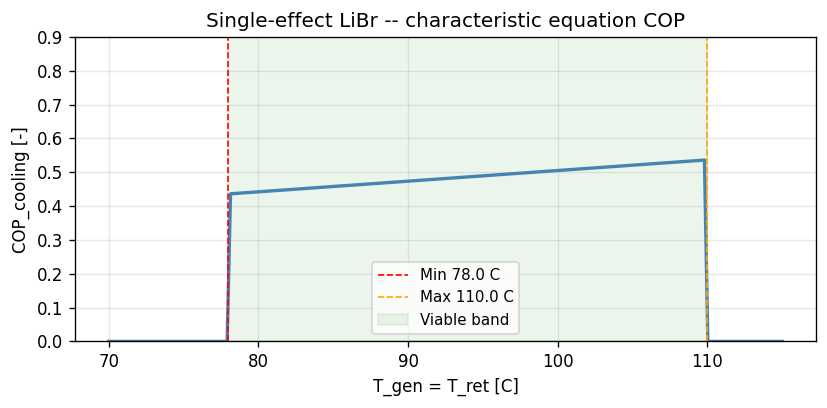

COP at key temperatures:
  T_ret = 78 C  -->  COP = 0.436
  T_ret = 85 C  -->  COP = 0.458
  T_ret = 95 C  -->  COP = 0.490
  T_ret = 105 C  -->  COP = 0.521
  T_ret = 110 C  -->  COP = 0.537


In [20]:
def COP_LiBr(T_gen):
    if T_gen < T_libr_min or T_gen > T_libr_max:
        return 0.0
    ddt = T_gen + T_evap - f_char * (T_cond + T_abs)
    return max(0., a_char + b_char * ddt)


def cold_output(mdot, cp, T_ret):
    Q_geo  = mdot * cp * max(T_ret - Tin, 0.)
    cop    = COP_LiBr(T_ret)
    Q_cold = Q_geo * cop
    Q_cold_RT = Q_cold / 3517.0 # 1 RT = 3.517 kW = 3517 W
    return Q_cold, Q_geo, cop, Q_cold_RT


T_gen_arr = np.linspace(70., 115., 200)
COP_arr   = [COP_LiBr(T) for T in T_gen_arr]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(T_gen_arr, COP_arr, 'steelblue', lw=2)
ax.axvline(T_libr_min, color='r',      ls='--', lw=1, label=f'Min {T_libr_min} C')
ax.axvline(T_libr_max, color='orange', ls='--', lw=1, label=f'Max {T_libr_max} C')
ax.fill_betweenx([0., 0.9], T_libr_min, T_libr_max,
                 alpha=0.08, color='green', label='Viable band')
ax.set_xlabel('T_gen = T_ret [C]'); ax.set_ylabel('COP_cooling [-]')
ax.set_title('Single-effect LiBr -- characteristic equation COP')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylim(0., 0.9)
plt.tight_layout(); plt.show()

print("COP at key temperatures:")
for T in [T_libr_min, 85., 95., 105., T_libr_max]:
    print(f"  T_ret = {T:.0f} C  -->  COP = {COP_LiBr(T):.3f}")

## Cell 9 · Coupled DBHE-Chiller Solver  *(auto-computed)*

In [21]:
def T_inf_z(z_arr):
    return T_surf + Gg * z_arr


def run_dbhe(Lbh, flow_rate_m3_h, kt, nz_param=NZ, neig_param=Neig, verbose=True):
    """Coupled BVP+GITT solver with time-stepped analytical tail correction.

    The GITT series is truncated at neig_param explicitly time-stepped modes.
    The remaining tail (modes neig_param+1 to infinity) is represented by a
    single lumped state variable U_tail that obeys the same GITT update rule:

        U_tail[k+1] = U_tail[k] * decay_tail
                    + R_tail * (1 - decay_tail) * q_eff[k]

    where
        R_tail    = R_ss - partial_sum(neig_param)  [K.m/W, exact via SS identity]
        decay_tail = exp(-alpha_e * beta_{N+1}^2 * dt)
        beta_{N+1} ~ beta_N + pi/Rfar  (next eigenvalue estimate)

    This makes the coupled output independent of neig_param once all
    dynamically significant modes (tau_n > dt) are explicitly retained.
    """
    label  = 'Bare' if kt > 1. else 'Insulated'
    T_mean = min((Tin + T_surf + Gg * Lbh * 0.6) / 2., 95.)
    pr     = water_props(T_mean)
    NTUat, NTUbw, mdot, va_annulus, v_tubing = compute_NTUs(flow_rate_m3_h, Lbh, pr, kt)

    # ── GITT Set A arrays ──────────────────────────────────────────────────
    (betas_arr_local, norms_arr_local, psi_rce_local, inv_wts_local,
     forc_coeff_local, tau_arr_local, decay_step_local) = _get_gitt_arrays(
        neig_param, rce, Rfar, ke, alpha_e, dt_step)

    # ── Tail correction parameters ─────────────────────────────────────────
    R_ss_val   = np.log(Rfar / rce) / (2. * np.pi * ke)
    partial    = np.sum(psi_rce_local**2 / (betas_arr_local**2 * norms_arr_local)) \
                 / (2. * np.pi * ke)
    R_tail     = R_ss_val - partial          # exact missing amplitude [K.m/W]
    beta_next  = betas_arr_local[-1] + np.pi / Rfar   # next eigenvalue estimate
    decay_tail = np.exp(-alpha_e * beta_next**2 * dt_step)

    if verbose:
        print(f"[{label}] Lbh={Lbh:.0f}m  Flow={flow_rate_m3_h:.1f}m3/h  "
              f"mdot={mdot:.3f}kg/s  va={va_annulus:.3f}m/s  vtb={v_tubing:.3f}m/s  "
              f"NTUat={NTUat:.3f}  NTUbw={NTUbw:.3f}")
        print(f"  Tail: R_ss={R_ss_val:.5f}  partial={partial:.5f}  "
              f"R_tail={R_tail:.5f} K.m/W  "
              f"({100.*R_tail/R_ss_val:.1f}% of R_ss)  "
              f"decay_tail/step={decay_tail:.5f}")

    dz_m   = Lbh / nz_param
    z_cc   = (np.arange(nz_param) + 0.5) * dz_m
    U_bar  = np.zeros((nz_param, neig_param))   # Set A GITT state
    U_tail = np.zeros(nz_param)                 # lumped tail state [K]
    Tbw    = T_inf_z(z_cc).copy()
    dT_sc  = max(Tbw.max() - Tin, 1.)

    # G_eff_ace [W/(m.K)]: annulus-to-borehole-wall conductance per unit length
    G_eff_ace = NTUbw * mdot * pr['cp'] / Lbh

    def _gitt_step(U_bar, U_tail, T_a_cc):
        q_bw  = G_eff_ace * (T_a_cc - Tbw)
        q_eff = q_bw * f_op
        # Set A update
        U_bar = (U_bar * decay_step_local[np.newaxis, :]
                 + forc_coeff_local[np.newaxis, :] * (1. - decay_step_local[np.newaxis, :])
                 * q_eff[:, np.newaxis])
        # Tail update: same GITT rule with scalar forcing coefficient R_tail
        U_tail = U_tail * decay_tail + R_tail * (1. - decay_tail) * q_eff
        T_bw_out = T_inf_z(z_cc) \
                   + (U_bar * inv_wts_local[np.newaxis, :]).sum(axis=1) \
                   + U_tail
        return U_bar, U_tail, T_bw_out

    def _cc(th): return 0.5 * (th[:-1] + th[1:])

    Tret_h     = np.zeros(n_steps)
    Qgeo_h     = np.zeros(n_steps)
    Qcold_h    = np.zeros(n_steps)
    COP_h      = np.zeros(n_steps)
    Qcold_RT_h = np.zeros(n_steps)
    viable     = np.zeros(n_steps, dtype=bool)

    steps_per_year = 365.25 / n_days_per_step
    print_interval = max(1, int(steps_per_year)) if steps_per_year >= 1 else n_steps

    for mo in range(n_steps):
        theta_bw            = (Tbw - Tin) / dT_sc
        ta, ttb             = solve_dbhe_bvp(NTUat, NTUbw, theta_bw, nz_param)
        T_a_cc              = Tin + _cc(ta) * dT_sc
        T_ret               = Tin + ttb[0]  * dT_sc
        U_bar, U_tail, Tbw  = _gitt_step(U_bar, U_tail, T_a_cc)
        dT_sc               = max(Tbw.max() - Tin, 1.)

        Q_cold, Q_geo, cop, Q_cold_RT = cold_output(mdot, pr['cp'], T_ret)
        Tret_h[mo]     = T_ret
        Qgeo_h[mo]     = Q_geo
        Qcold_h[mo]    = Q_cold
        COP_h[mo]      = cop
        Qcold_RT_h[mo] = Q_cold_RT
        viable[mo]     = T_ret >= T_libr_min

        if verbose and (mo % print_interval == 0 or mo == n_steps - 1):
            yr     = (mo + 1) * n_days_per_step / 365.25
            status = 'OK' if T_ret >= T_libr_min else 'END-OF-LIFE'
            print(f"  Year {yr:5.1f}: Tret={T_ret:.1f} C  "
                  f"Q_geo={Q_geo/1e3:.1f} kW  "
                  f"Q_cold={Q_cold/1e3:.1f} kW  "
                  f"COP={cop:.3f}  [{status}]")

    eol_steps  = int(np.argmax(~viable)) if not viable.all() else n_steps
    eol_years  = eol_steps * n_days_per_step / 365.25
    total_GWh  = float(Qcold_h.sum()) * dt_step * f_op / 3.6e9

    ta_profile_final  = Tin + ta  * dT_sc
    ttb_profile_final = Tin + ttb * dT_sc

    return dict(
        Tret=Tret_h, Qgeo=Qgeo_h, Qcold=Qcold_h, COP=COP_h,
        viable=viable, eol_years=eol_years, label=label,
        Lbh=Lbh, flow_rate_m3_h=flow_rate_m3_h, kt=kt, mdot=mdot,
        va_annulus=va_annulus, v_tubing=v_tubing,
        NTUat=NTUat, NTUbw=NTUbw,
        total_cold_GWh=total_GWh,
        Qcold_RT=Qcold_RT_h,
        ta_profile=ta_profile_final,
        ttb_profile=ttb_profile_final,
        R_tail=float(R_tail), R_ss=float(R_ss_val),
    )


## Cell 10 · Demo Run

In [22]:
print("=" * 60)
print("Case A: Bare steel tubing")
print("=" * 60)
res_bare = run_dbhe(Lbh=Lbh_default, flow_rate_m3_h=flow_rate_m3_h_demo, kt=kt_bare, verbose=True)

print()
print("=" * 60)
print("Case B: Insulated (VIT) tubing")
print("=" * 60)
res_ins = run_dbhe(Lbh=Lbh_default, flow_rate_m3_h=flow_rate_m3_h_demo, kt=kt_insulated, verbose=True)

Case A: Bare steel tubing
[Bare] Lbh=4500m  Flow=10.0m3/h  mdot=2.714kg/s  va=0.176m/s  vtb=0.921m/s  NTUat=78.371  NTUbw=11.467
  Tail: R_ss=0.54434  partial=0.36966  R_tail=0.17468 K.m/W  (32.1% of R_ss)  decay_tail/step=0.97956
  Year   0.0: Tret=25.2 C  Q_geo=2.7 kW  Q_cold=0.0 kW  COP=0.000  [END-OF-LIFE]
  Year   1.0: Tret=26.1 C  Q_geo=12.5 kW  Q_cold=0.0 kW  COP=0.000  [END-OF-LIFE]
  Year   2.0: Tret=26.1 C  Q_geo=12.7 kW  Q_cold=0.0 kW  COP=0.000  [END-OF-LIFE]
  Year   3.0: Tret=26.1 C  Q_geo=12.9 kW  Q_cold=0.0 kW  COP=0.000  [END-OF-LIFE]
  Year   4.0: Tret=26.1 C  Q_geo=12.9 kW  Q_cold=0.0 kW  COP=0.000  [END-OF-LIFE]
  Year   5.0: Tret=26.1 C  Q_geo=13.0 kW  Q_cold=0.0 kW  COP=0.000  [END-OF-LIFE]
  Year   6.0: Tret=26.1 C  Q_geo=13.0 kW  Q_cold=0.0 kW  COP=0.000  [END-OF-LIFE]
  Year   7.0: Tret=26.2 C  Q_geo=13.1 kW  Q_cold=0.0 kW  COP=0.000  [END-OF-LIFE]
  Year   8.0: Tret=26.2 C  Q_geo=13.1 kW  Q_cold=0.0 kW  COP=0.000  [END-OF-LIFE]
  Year   9.0: Tret=26.2 C  Q_geo

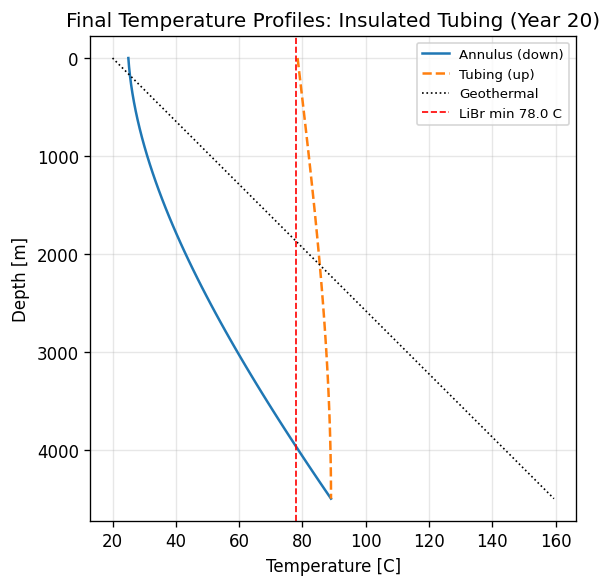

In [23]:
# Plot final temperature profiles for the Insulated (VIT) case
fig, ax = plt.subplots(figsize=(5, 5))

# Geothermal depth array
z_plot = np.linspace(0., res_ins['Lbh'], NZ+1)

# Plot annulus and tubing profiles
ax.plot(res_ins['ta_profile'], z_plot, label='Annulus (down)')
ax.plot(res_ins['ttb_profile'], z_plot, label='Tubing (up)', ls='--')

# Plot geothermal temperature profile
ax.plot(T_surf + Gg * z_plot, z_plot, color='k', ls=':', lw=1, label='Geothermal')

# Add LiBr min threshold
ax.axvline(T_libr_min, color='r', ls='--', lw=1, label=f'LiBr min {T_libr_min} C')

ax.set_xlabel('Temperature [C]')
ax.set_ylabel('Depth [m]')
ax.set_title(f'Final Temperature Profiles: Insulated Tubing (Year {n_years})')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Cell 11 · Formation Model Comparison — GITT vs ICS vs ILS (coupled solver, 20 years)

Validates the GITT formation model against the ICS and ILS analytical solutions
in the context of the **coupled BVP solver** under the dynamic heat flux produced
by the 20-year cooling simulation. This complements Cell 15 (constant-flux benchmark)
by testing the formation model under realistic, time-varying forcing.

**Method.** The GITT coupled solver is run once (20 years, baseline parameters).
The annual-average heat flux profile $q_{\mathrm{eff}}(z)$ is stored for each year.
The ICS and ILS borehole wall temperatures are then computed via annual-step
superposition:

$$T_{\mathrm{bw}}^{\mathrm{ILS/ICS}}(z,\,t_N)
= T_\infty(z)
+ \sum_{k=0}^{N-1}
  \bigl[R_{\mathrm{form}}(t_N - t_k) - R_{\mathrm{form}}(t_N - t_{k+1})\bigr]
  \,\bar{q}_{\mathrm{eff},k}(z)$$

where $\bar{q}_{\mathrm{eff},k}(z)$ is the annual-average effective heat flux in
year $k$, $t_k = k$ years, and $R_{\mathrm{form}}(t)$ is either:

- **ILS:** $R_{\mathrm{form}}^{\mathrm{ILS}}(t) = \dfrac{1}{4\pi k_e}\,
  E_1\!\left(\dfrac{r_{ce}^2}{4\alpha_e t}\right)$

- **ICS:** $R_{\mathrm{form}}^{\mathrm{ICS}}(t)$ obtained by numerical inversion
  (Stehfest algorithm, $N=12$) of
  $\bar{R}(s) = \dfrac{K_0(\xi)}{2\pi k_e\,s\,\xi\,K_1(\xi)}$,
  $\xi = r_{ce}\sqrt{s/\alpha_e}$

The $T_{\mathrm{bw}}$ profile from each model is fed into the BVP solver to recover
$T_{\mathrm{ret}}$. No re-coupling is performed — this is a post-processing comparison.

**Expected behaviour.** ICS and ILS should agree to within 0.01 K at all years
(both are exact for an infinite medium at $F_o \gg 5$). GITT should sit slightly
above both at early years due to correct handling of the declining flux history,
converging to within 0.1 K by year 5 as the flux stabilises.


Running GITT coupled solver (20 yr) and accumulating annual q_eff...
  GITT done.  T_ret yr1=86.55 C  yr20=78.49 C
Computing ICS and ILS superposition... done.
  ICS  T_ret yr1=84.88 C  yr20=78.46 C
  ILS  T_ret yr1=84.89 C  yr20=78.46 C

 Year    T_GITT     T_ICS     T_ILS    GITT-ICS    GITT-ILS
----------------------------------------------------------
    1    86.551    84.880    84.888      1.6706      1.6624
    2    84.499    84.080    84.084      0.4191      0.4151
    5    81.964    81.831    81.832      0.1336      0.1320
   10    80.175    80.114    80.115      0.0606      0.0598
   15    79.176    79.138    79.138      0.0386      0.0381
   20    78.488    78.460    78.460      0.0282      0.0278


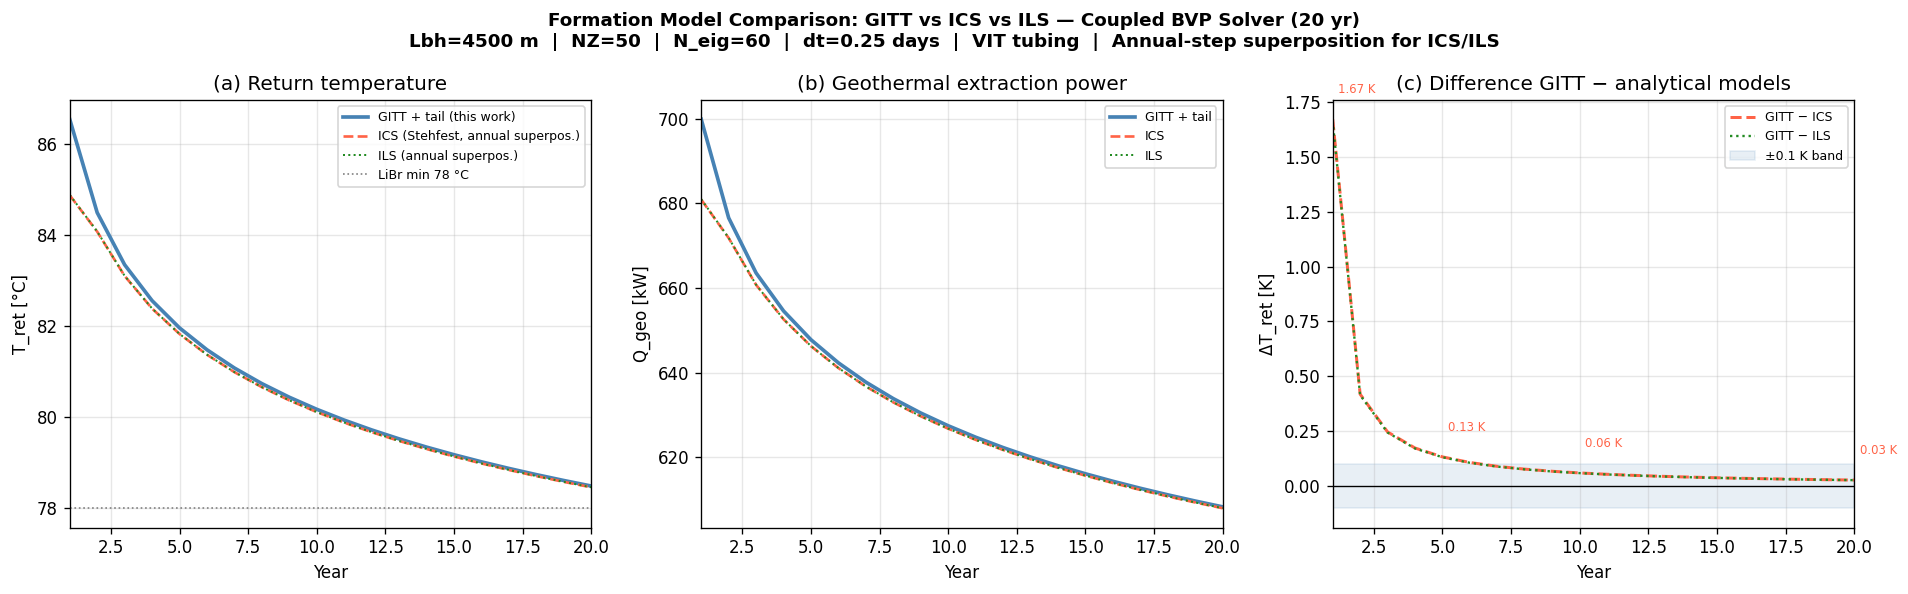

Figure saved: gitt_vs_ils_ics.png


In [24]:
# ── Cell 16: GITT vs ICS vs ILS in the coupled solver (20-year comparison) ─
from scipy.special import exp1, k0 as _k0, k1 as _k1
from math import factorial as _fact

# ── Stehfest weights (N=12) ───────────────────────────────────────────────
def _stehfest_weights(N=12):
    V = np.zeros(N)
    for i in range(1, N+1):
        s = 0.
        for k2 in range(int((i+1)//2), min(i, N//2)+1):
            s += (k2**(N//2) * _fact(2*k2) /
                  (_fact(N//2-k2)*_fact(k2)*_fact(k2-1)*
                   _fact(i-k2)*_fact(2*k2-i)))
        V[i-1] = (-1)**(i+N//2) * s
    return V

_V_st = _stehfest_weights(12)

def R_ICS(t_sec):
    """ICS thermal resistance [m·K/W] via Stehfest inversion.
    Laplace transform: R_bar(s) = K0(xi)/(2*pi*ke*s*xi*K1(xi)),  xi=rce*sqrt(s/alpha_e).
    """
    if t_sec <= 0.: return 0.
    ln2_t = np.log(2.) / t_sec
    R_sum = 0.
    for i in range(12):
        s  = (i+1) * ln2_t
        xi = rce * np.sqrt(s / alpha_e)
        k0v = _k0(xi); k1v = _k1(xi)
        if xi * k1v < 1e-300: continue
        R_sum += _V_st[i] * k0v / (2.*np.pi*ke * s * xi * k1v)
    return max(R_sum * ln2_t, 0.)

def R_ILS(t_sec):
    """ILS thermal resistance [m·K/W].
    R(t) = E1(rce^2 / (4*alpha_e*t)) / (4*pi*ke).
    """
    if t_sec <= 0.: return 0.
    return exp1(rce**2 / (4.*alpha_e*t_sec)) / (4.*np.pi*ke)

# ── Step 1: run GITT coupled solver and store annual average q_eff ────────
print('Running GITT coupled solver (20 yr) and accumulating annual q_eff...')
_n_steps_c16 = int(n_years * 365.25 / n_days_per_step)
_spy_c16     = 365.25 / n_days_per_step   # steps per year
_n_yr        = n_years

_dz_m   = Lbh_default / NZ
_z_cc   = (np.arange(NZ) + 0.5) * _dz_m
_T_inf  = T_surf + Gg * _z_cc

# NTUs for baseline operating point
_pr     = water_props(min((Tin + T_surf + Gg * Lbh_default * 0.6) / 2., 95.))
_NTUat, _NTUbw, _mdot, _, _ = compute_NTUs(
    flow_rate_m3_h_demo, Lbh_default, _pr, kt_demo)
_G_eff  = _NTUbw * _mdot * _pr['cp'] / Lbh_default

# GITT arrays (baseline Neig, dt)
(_betas, _norms_g, _psi_rce, _inv_wts,
 _forc, _tau, _decay) = _get_gitt_arrays(
    Neig, rce, Rfar, ke, alpha_e, dt_step)
_R_ss     = np.log(Rfar / rce) / (2.*np.pi*ke)
_R_tail   = _R_ss - np.sum(_psi_rce**2 / (_betas**2 * _norms_g)) / (2.*np.pi*ke)
_b_next   = _betas[-1] + np.pi / Rfar
_d_tail   = np.exp(-alpha_e * _b_next**2 * dt_step)

_U_bar  = np.zeros((NZ, Neig))
_U_tail = np.zeros(NZ)
_Tbw    = _T_inf.copy()
_dT_sc  = max(_Tbw.max() - Tin, 1.)

def _cc16(th): return 0.5*(th[:-1]+th[1:])

_q_ann   = np.zeros((_n_yr, NZ))   # annual average q_eff [W/m]
_Tret_g  = np.zeros(_n_yr)
_Qgeo_g  = np.zeros(_n_yr)
_q_acc   = np.zeros(NZ); _st_acc = 0; _yr_i = 0
_sbin    = int(_spy_c16)   # steps per annual bin

for _mo in range(_n_steps_c16):
    _theta_bw = (_Tbw - Tin) / _dT_sc
    _ta, _ttb = solve_dbhe_bvp(_NTUat, _NTUbw, _theta_bw, NZ)
    _T_ret    = Tin + _ttb[0] * _dT_sc
    _T_a_cc   = Tin + _cc16(_ta) * _dT_sc
    _q_bw     = _G_eff * (_T_a_cc - _Tbw)
    _q_eff    = _q_bw * f_op
    _U_bar    = (_U_bar * _decay[np.newaxis, :]
                 + _forc[np.newaxis, :] * (1. - _decay[np.newaxis, :])
                 * _q_eff[:, np.newaxis])
    _U_tail   = _U_tail * _d_tail + _R_tail * (1. - _d_tail) * _q_eff
    _Tbw      = _T_inf + (_U_bar * _inv_wts[np.newaxis, :]).sum(axis=1) + _U_tail
    _dT_sc    = max(_Tbw.max() - Tin, 1.)
    _q_acc   += _q_eff; _st_acc += 1
    if (_mo+1) % _sbin == 0 and _yr_i < _n_yr:
        _q_ann[_yr_i]  = _q_acc / _st_acc
        _Tret_g[_yr_i] = _T_ret
        _Qgeo_g[_yr_i] = _mdot * _pr['cp'] * max(_T_ret - Tin, 0.)
        _q_acc[:] = 0.; _st_acc = 0; _yr_i += 1

print(f'  GITT done.  T_ret yr1={_Tret_g[0]:.2f} C  yr20={_Tret_g[-1]:.2f} C')

# ── Step 2: ICS / ILS superposition at each year ─────────────────────────
print('Computing ICS and ILS superposition...', end=' ', flush=True)
_t_bin  = 365.25 * t_day   # 1 year per bin [s]
_Tret_c = np.zeros(_n_yr); _Tret_l = np.zeros(_n_yr)
_Qgeo_c = np.zeros(_n_yr); _Qgeo_l = np.zeros(_n_yr)

def _Tbw_super(t_N_yr, R_func):
    """T_bw(z) at t_N_yr years via annual-step superposition."""
    Tbw_z = _T_inf.copy()
    for k in range(int(t_N_yr)):
        dR = R_func((t_N_yr - k)     * _t_bin) - \
             R_func((t_N_yr - k - 1) * _t_bin)
        Tbw_z += dR * _q_ann[k]
    return Tbw_z

for _yi in range(_n_yr):
    _tN = float(_yi + 1)
    for _Rfunc, _Tr, _Qr in [(R_ICS, _Tret_c, _Qgeo_c),
                              (R_ILS, _Tret_l, _Qgeo_l)]:
        _Tbw_loc = _Tbw_super(_tN, _Rfunc)
        _dsc_loc = max(_Tbw_loc.max() - Tin, 1.)
        _th_bw   = (_Tbw_loc - Tin) / _dsc_loc
        _ta_loc, _ttb_loc = solve_dbhe_bvp(_NTUat, _NTUbw, _th_bw, NZ)
        _Tr[_yi] = Tin + _ttb_loc[0] * _dsc_loc
        _Qr[_yi] = _mdot * _pr['cp'] * max(_Tr[_yi] - Tin, 0.)

print('done.')
print(f'  ICS  T_ret yr1={_Tret_c[0]:.2f} C  yr20={_Tret_c[-1]:.2f} C')
print(f'  ILS  T_ret yr1={_Tret_l[0]:.2f} C  yr20={_Tret_l[-1]:.2f} C')

# ── Results table ─────────────────────────────────────────────────────────
print()
print(f"{'Year':>5}  {'T_GITT':>8}  {'T_ICS':>8}  {'T_ILS':>8}  "
      f"{'GITT-ICS':>10}  {'GITT-ILS':>10}")
print('-' * 58)
for _yr in [1, 2, 5, 10, 15, 20]:
    _i = _yr - 1
    print(f"{_yr:>5}  {_Tret_g[_i]:>8.3f}  {_Tret_c[_i]:>8.3f}  {_Tret_l[_i]:>8.3f}  "
          f"{_Tret_g[_i]-_Tret_c[_i]:>10.4f}  {_Tret_g[_i]-_Tret_l[_i]:>10.4f}")

# ── Figure ────────────────────────────────────────────────────────────────
_t_yr = np.arange(1, _n_yr+1, dtype=float)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) T_ret
ax = axes[0]
ax.plot(_t_yr, _Tret_g, color='steelblue', lw=2.2, label='GITT + tail (this work)')
ax.plot(_t_yr, _Tret_c, color='tomato',    lw=1.6, ls='--', label='ICS (Stehfest, annual superpos.)')
ax.plot(_t_yr, _Tret_l, color='forestgreen', lw=1.2, ls=':', label='ILS (annual superpos.)')
ax.axhline(T_libr_min, color='gray', ls=':', lw=1., label=f'LiBr min {T_libr_min:.0f} °C')
ax.set_xlabel('Year'); ax.set_ylabel('T_ret [°C]')
ax.set_title('(a) Return temperature'); ax.legend(fontsize=7.5)
ax.grid(True, alpha=0.3); ax.set_xlim(1, 20)

# (b) Q_geo
ax = axes[1]
ax.plot(_t_yr, _Qgeo_g/1e3, color='steelblue', lw=2.2, label='GITT + tail')
ax.plot(_t_yr, _Qgeo_c/1e3, color='tomato',    lw=1.6, ls='--', label='ICS')
ax.plot(_t_yr, _Qgeo_l/1e3, color='forestgreen', lw=1.2, ls=':', label='ILS')
ax.set_xlabel('Year'); ax.set_ylabel('Q_geo [kW]')
ax.set_title('(b) Geothermal extraction power'); ax.legend(fontsize=7.5)
ax.grid(True, alpha=0.3); ax.set_xlim(1, 20)

# (c) Difference GITT - ICS and GITT - ILS
ax = axes[2]
ax.plot(_t_yr, _Tret_g - _Tret_c, color='tomato',    lw=1.8, ls='--', label='GITT − ICS')
ax.plot(_t_yr, _Tret_g - _Tret_l, color='forestgreen', lw=1.4, ls=':',  label='GITT − ILS')
ax.axhline(0., color='k', lw=0.8)
ax.fill_between(_t_yr, -0.1, 0.1, alpha=0.12, color='steelblue', label='±0.1 K band')
for _yr in [1, 5, 10, 20]:
    _i = _yr-1
    ax.annotate(f'{_Tret_g[_i]-_Tret_c[_i]:.2f} K',
                xy=(_yr, _Tret_g[_i]-_Tret_c[_i]),
                xytext=(_yr+0.2, _Tret_g[_i]-_Tret_c[_i]+0.12),
                fontsize=7, color='tomato')
ax.set_xlabel('Year'); ax.set_ylabel('ΔT_ret [K]')
ax.set_title('(c) Difference GITT − analytical models'); ax.legend(fontsize=7.5)
ax.grid(True, alpha=0.3); ax.set_xlim(1, 20)

plt.suptitle(
    f'Formation Model Comparison: GITT vs ICS vs ILS — Coupled BVP Solver (20 yr)\n'
    f'Lbh={Lbh_default:.0f} m  |  NZ={NZ}  |  N_eig={Neig}  |  '
    f'dt={n_days_per_step} days  |  VIT tubing  |  Annual-step superposition for ICS/ILS',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('gitt_vs_ils_ics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: gitt_vs_ils_ics.png')
